NAME : MOHD RAZA, ROLL NO : 35, SECTION : B

# Experiment No. 4 — Advanced Data Visualization using Matplotlib and Seaborn

**Dataset used:** Sample Superstore Dataset (US retail orders — Sales, Profit, Discount, Quantity
across Regions, Categories, Sub-Categories, and Order Dates)

**Aim:** To create and analyze various data visualizations using Matplotlib and Seaborn in order
to identify trends, patterns, correlations, and insights from a real-world dataset.


## Step 2: Import libraries and load the cleaned dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


## Step 3: Bar Charts — comparing categorical variables

/tmp/ipykernel_501/1117050588.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='viridis')


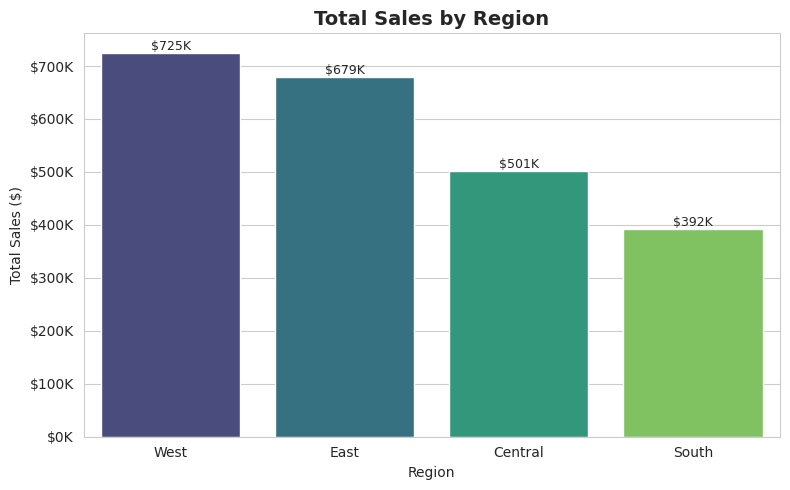

In [ ]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=sales_by_region.index, y=sales_by_region.values, palette='viridis')
ax.set_title('Total Sales by Region', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
for i, v in enumerate(sales_by_region.values):
    ax.text(i, v, f'${v/1000:.0f}K', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('bar_sales_by_region.png', dpi=120)
plt.show()


/tmp/ipykernel_501/412475744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sales_by_category.values, y=sales_by_category.index, palette='mako')


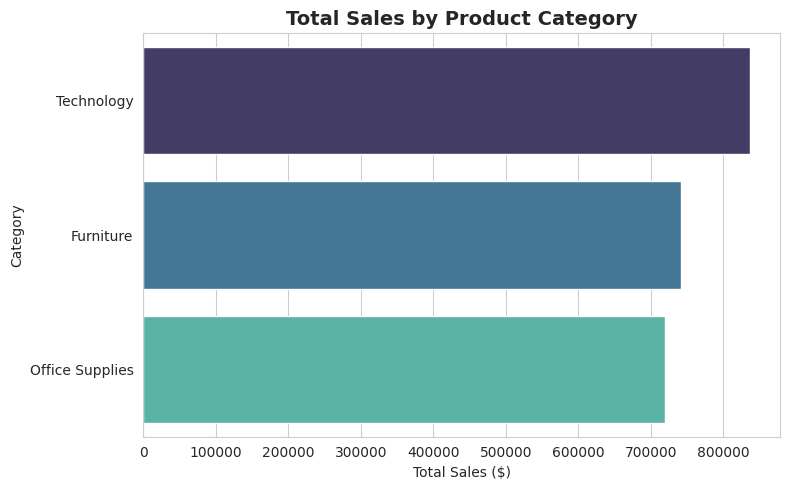

In [ ]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=sales_by_category.values, y=sales_by_category.index, palette='mako')
ax.set_title('Total Sales by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('bar_sales_by_category.png', dpi=120)
plt.show()


**Insight:** The West region generates the highest total sales, followed by East. Technology
and Office Supplies together account for the majority of revenue, with Furniture trailing behind
despite similar order volumes seen in earlier experiments.

## Step 4: Line Chart — sales trend over time

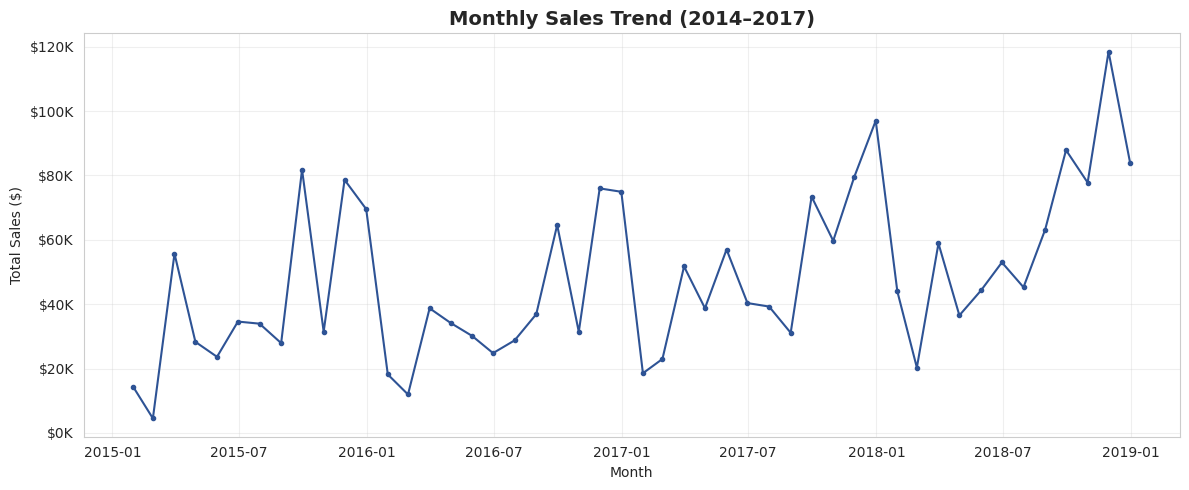

In [ ]:
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o', markersize=3, color='#2E5395', linewidth=1.5)
plt.title('Monthly Sales Trend (2014–2017)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:,.0f}K'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('line_monthly_sales.png', dpi=120)
plt.show()


**Insight:** Sales show a clear seasonal pattern, spiking every November-December
(holiday/year-end purchasing) and dipping in the early months of each year. There is also a
gradual upward trend across the four years, suggesting overall business growth.

## Step 5: Histograms — distribution of numerical variables

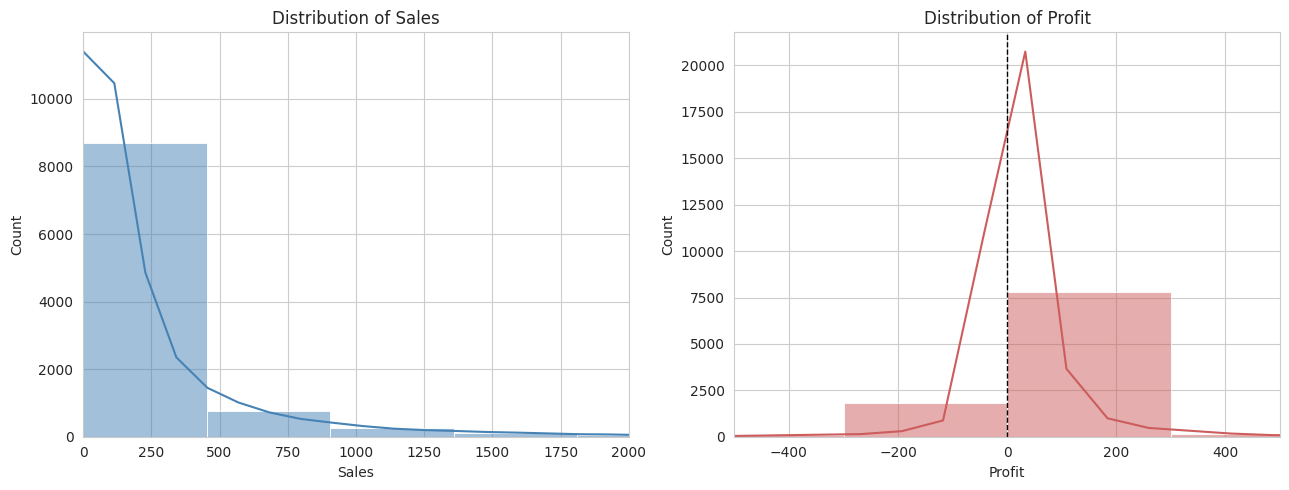

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.histplot(df['Sales'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Sales')
axes[0].set_xlim(0, 2000)

sns.histplot(df['Profit'], bins=50, kde=True, ax=axes[1], color='indianred')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Distribution of Profit')
axes[1].set_xlim(-500, 500)
plt.tight_layout()
plt.savefig('histograms_sales_profit.png', dpi=120)
plt.show()


**Insight:** Sales is strongly right-skewed, with most orders being small and a long tail of
large-value orders. Profit is roughly centered near zero but with a visible cluster of negative
values, indicating a meaningful share of loss-making orders.

## Step 6: Box Plots — outliers and category comparison

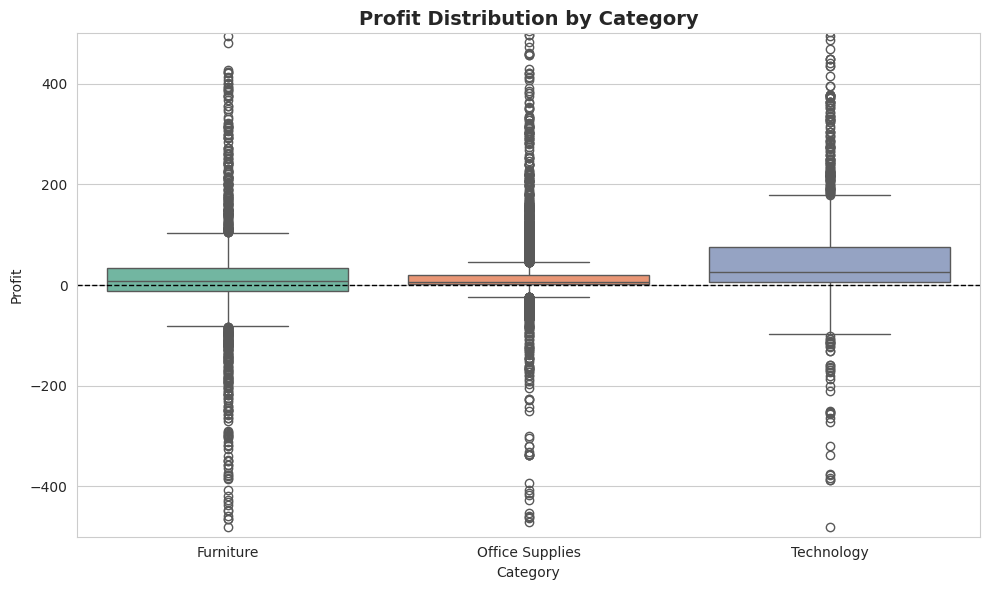

In [ ]:
plt.figure(figsize=(10,6))
ax = sns.boxplot(data=df, x='Category', y='Profit', hue='Category', palette='Set2', legend=False)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Profit Distribution by Category', fontsize=14, fontweight='bold')
ax.set_ylim(-500, 500)
plt.tight_layout()
plt.savefig('boxplot_profit_category.png', dpi=120)
plt.show()


**Insight:** Furniture shows the widest spread of negative-profit outliers among the three
categories, confirming it as the least consistently profitable category, while Technology's
box sits higher and tighter around a positive median profit.

## Step 7: Scatter Plot — relationship between two numerical variables

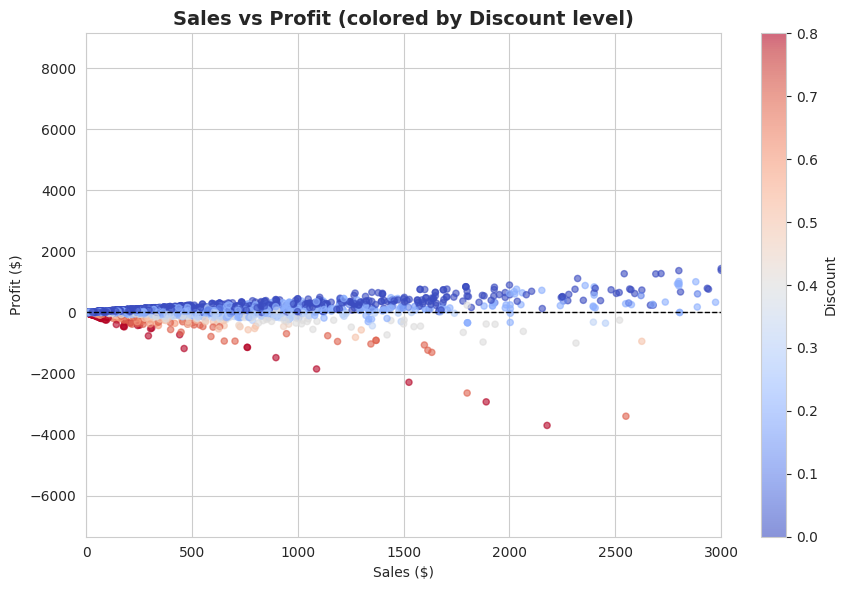

In [ ]:
plt.figure(figsize=(9,6))
scatter = plt.scatter(df['Sales'], df['Profit'], c=df['Discount'], cmap='coolwarm', alpha=0.6, s=20)
plt.colorbar(scatter, label='Discount')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlim(0, 3000)
plt.title('Sales vs Profit (colored by Discount level)', fontsize=14, fontweight='bold')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.tight_layout()
plt.savefig('scatter_sales_profit.png', dpi=120)
plt.show()


**Insight:** Higher-discount orders (warmer colors) cluster in the negative-profit region even
at moderate-to-high sales values, visually confirming that discounting — not sales volume — is the
strongest driver of unprofitable transactions.

## Step 8: Correlation Heatmap

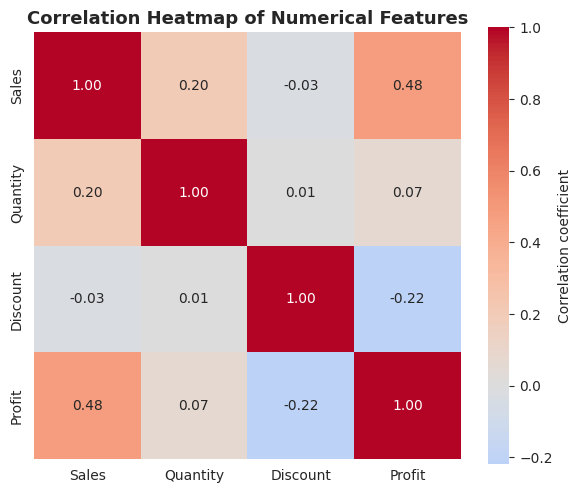

In [ ]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr = df[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            cbar_kws={'label': 'Correlation coefficient'})
plt.title('Correlation Heatmap of Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120)
plt.show()


**Insight:** Discount is negatively correlated with Profit, while Sales and Profit show only a
weak positive relationship — reinforcing that pricing strategy, not raw sales volume, is the
bigger lever on profitability.

## Step 9: Chart Customization Example

The chart below demonstrates full customization — descriptive title, labeled axes, a legend,
direct data-label annotations, and a deliberate color palette — applied to a single, polished
figure summarizing regional profit performance.


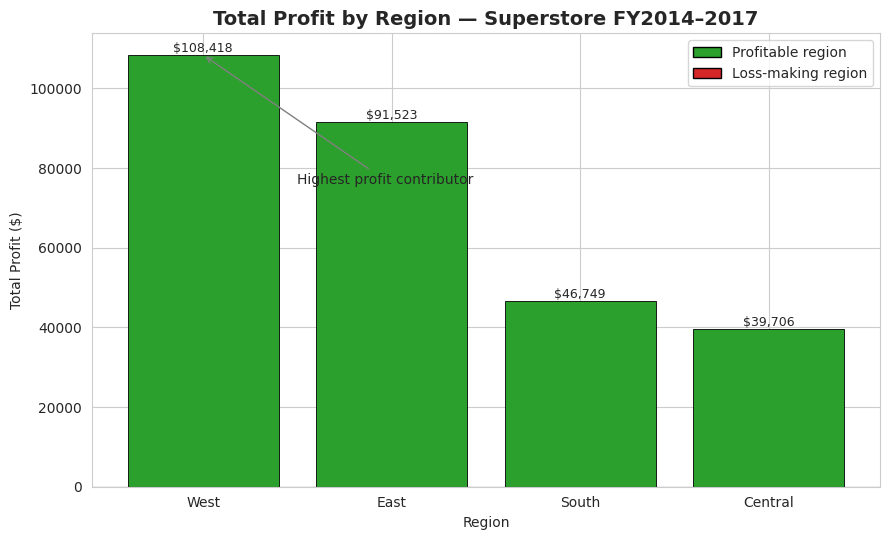

In [ ]:
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
colors = ['#2ca02c' if v > 0 else '#d62728' for v in profit_by_region.values]

plt.figure(figsize=(9,5.5))
bars = plt.bar(profit_by_region.index, profit_by_region.values, color=colors, edgecolor='black', linewidth=0.6)
plt.title('Total Profit by Region — Superstore FY2014–2017', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.axhline(0, color='black', linewidth=0.8)

for bar, value in zip(bars, profit_by_region.values):
    plt.text(bar.get_x() + bar.get_width()/2, value, f'${value:,.0f}',
              ha='center', va='bottom' if value >= 0 else 'top', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', edgecolor='black', label='Profitable region'),
                    Patch(facecolor='#d62728', edgecolor='black', label='Loss-making region')]
plt.legend(handles=legend_elements, loc='upper right')

plt.annotate('Highest profit contributor', xy=(profit_by_region.index[0], profit_by_region.values[0]),
             xytext=(0.5, profit_by_region.values[0]*0.7), textcoords='data',
             arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.savefig('customized_profit_by_region.png', dpi=120)
plt.show()


## Step 10: Summary of Key Business Insights

1. **Regional performance:** West leads in both sales and profit; Central lags and is the region
   most at risk of falling into overall loss once Furniture underperformance is factored in.
2. **Seasonality:** Sales peak sharply every November–December, useful for inventory and staffing
   planning ahead of year-end demand.
3. **Category profitability:** Technology is the most reliably profitable category; Furniture is
   the most volatile, with the widest spread of loss-making orders.
4. **Discount is the key lever:** Across histograms, scatter plots, and the correlation heatmap,
   discounting consistently emerges as the strongest driver of reduced or negative profit — more
   so than order size or sales volume.
5. **Visualization choice matters:** Bar charts made regional/category comparisons immediate, the
   line chart revealed seasonality invisible in aggregate totals, and the scatter plot surfaced the
   discount–profit relationship far more intuitively than a correlation number alone.
